In [5]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\saisn\OneDrive\Desktop\customer-churn-analysis\.venv\Scripts\python.exe
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [6]:
%pip install pandas openpyxl matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import openpyxl
import matplotlib
import seaborn as sns

print("Pandas:", pd.__version__)
print("OpenPyXL:", openpyxl.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

Pandas: 3.0.6
OpenPyXL: 3.1.5
Matplotlib: 3.11.2
Seaborn: 0.13.2


In [8]:
import pandas as pd

file_path = "../data/raw/Telco_customer_churn.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 33


In [9]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. CustomerID
2. Count
3. Country
4. State
5. City
6. Zip Code
7. Lat Long
8. Latitude
9. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason


In [10]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [11]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset shape: (7043, 33)

Data types:
CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtyp

In [12]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Churn Reason    5174
dtype: int64


In [13]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [14]:
print("Unique values in key columns:\n")

for column in [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Internet Service",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Churn Label"
]:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))

Unique values in key columns:


Gender:
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Senior Citizen:
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Phone Service:
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Internet Service:
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Paperless Billing:
Paperless Billing
Yes    4171
No     2872
Name: count, dtype: int64

Payment Method:
Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Churn Label:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int6

In [15]:
for column in [
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Phone Service ---
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

--- Multiple Lines ---
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- Internet Service ---
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- Online Security ---
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- Online Backup ---
Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- Device Protection ---
Device Protection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

--- Tech Support ---
Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

--- Streaming TV ---
Streaming TV
No         

In [16]:
numeric_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Value",
    "Churn Score",
    "CLTV"
]

print(df[numeric_columns].describe().T)

                  count         mean          std      min     25%      50%  \
Tenure Months    7043.0    32.371149    24.559481     0.00     9.0    29.00   
Monthly Charges  7043.0    64.761692    30.090047    18.25    35.5    70.35   
Churn Value      7043.0     0.265370     0.441561     0.00     0.0     0.00   
Churn Score      7043.0    58.699418    21.525131     5.00    40.0    61.00   
CLTV             7043.0  4400.295755  1183.057152  2003.00  3469.0  4527.00   

                     75%      max  
Tenure Months      55.00    72.00  
Monthly Charges    89.85   118.75  
Churn Value         1.00     1.00  
Churn Score        75.00   100.00  
CLTV             5380.50  6500.00  


In [17]:
print("Data type:", df["Total Charges"].dtype)

print("\nBlank values:")
print((df["Total Charges"].astype(str).str.strip() == "").sum())

print("\nSample values:")
print(df["Total Charges"].head(10).tolist())

Data type: object

Blank values:
11

Sample values:
[108.15, 151.65, 820.5, 3046.05, 5036.3, 528.35, 39.65, 20.15, 4749.15, 30.2]


In [18]:
blank_total_charges = df[
    df["Total Charges"].astype(str).str.strip() == ""
]

print(blank_total_charges[
    ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]
])

      CustomerID  Tenure Months  Monthly Charges Total Charges Churn Label
2234  4472-LVYGI              0            52.55                        No
2438  3115-CZMZD              0            20.25                        No
2568  5709-LVOEQ              0            80.85                        No
2667  4367-NUYAO              0            25.75                        No
2856  1371-DWPAZ              0            56.05                        No
4331  7644-OMVMY              0            19.85                        No
4687  3213-VVOLG              0            25.35                        No
5104  2520-SGTTA              0            20.00                        No
5719  2923-ARZLG              0            19.70                        No
6772  4075-WKNIU              0            73.35                        No
6840  2775-SEFEE              0            61.90                        No


In [19]:
# Convert blank Total Charges to 0
df["Total Charges"] = df["Total Charges"].replace(r"^\s*$", "0", regex=True)

# Convert the column to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"])

print("Data type:", df["Total Charges"].dtype)
print("Missing values:", df["Total Charges"].isna().sum())
print("Minimum:", df["Total Charges"].min())
print("Maximum:", df["Total Charges"].max())

Data type: float64
Missing values: 0
Minimum: 0.0
Maximum: 8684.8


In [20]:
output_path = "../data_cleaned/telco_customer_churn_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
../data_cleaned/telco_customer_churn_cleaned.csv


In [21]:
churn_rate = df["Churn Value"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


In [22]:
contract_churn = (
    df.groupby("Contract")["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print("Churn rate by contract type:")
print(contract_churn)

Churn rate by contract type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn Value, dtype: float64


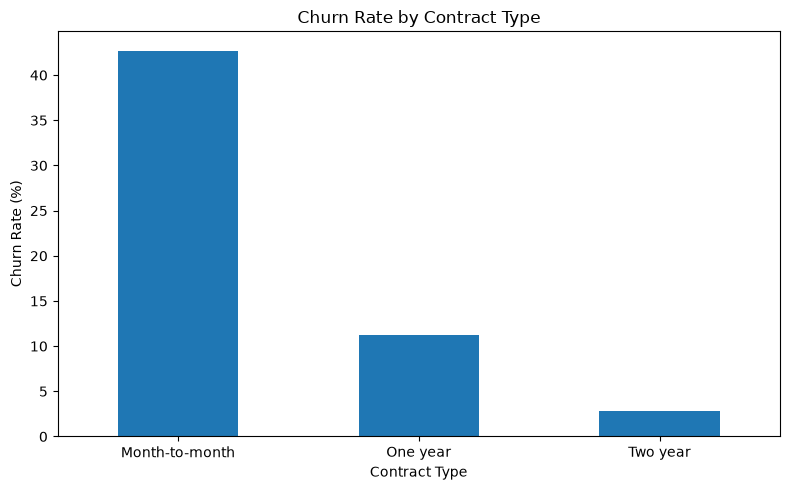

In [23]:
import matplotlib.pyplot as plt

contract_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
tenure_churn = (
    df.groupby("Tenure Months")["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
)

print(tenure_churn)

Tenure Months
0      0.00
1     61.99
2     51.68
3     47.00
4     47.16
      ...  
68     9.00
69     8.42
70     9.24
71     3.53
72     1.66
Name: Churn Value, Length: 73, dtype: float64


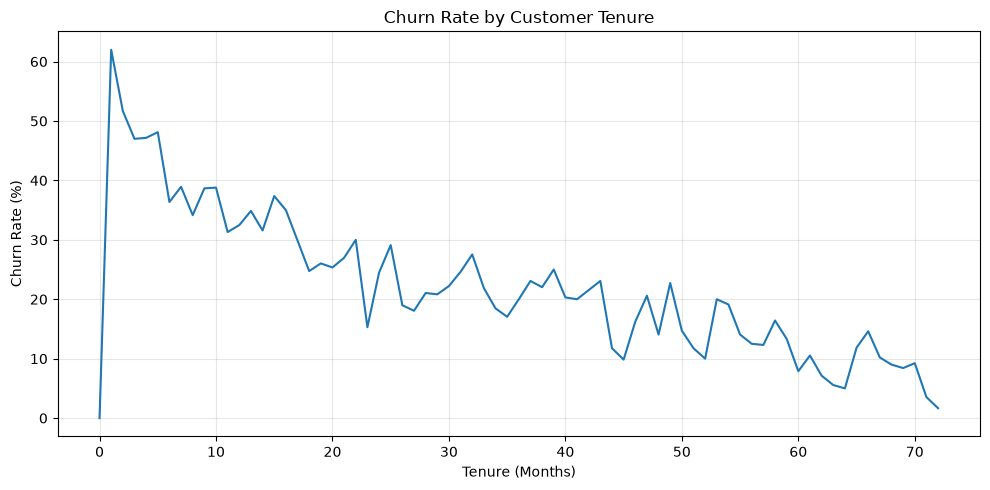

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(tenure_churn.index, tenure_churn.values)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
df.groupby("Churn Label")["Monthly Charges"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Churn Label,,,
No,5174,61.27,64.43
Yes,1869,74.44,79.65


In [28]:
df["Monthly Charge Band"] = pd.cut(
    df["Monthly Charges"],
    bins=[0, 30, 60, 90, 120],
    labels=["Under $30", "$30–60", "$60–90", "$90+"]
)

charge_churn = (
    df.groupby("Monthly Charge Band", observed=True)["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
)

print("Churn rate by monthly charge band:")
print(charge_churn)

Churn rate by monthly charge band:
Monthly Charge Band
Under $30     9.80
$30–60       25.93
$60–90       33.91
$90+         32.78
Name: Churn Value, dtype: float64


In [29]:
internet_churn = (
    df.groupby("Internet Service")["Churn Value"]
      .agg(["count", "mean"])
)

internet_churn["Churn Rate (%)"] = (
    internet_churn["mean"] * 100
).round(2)

internet_churn = internet_churn.drop(columns="mean")

print(internet_churn)

                  count  Churn Rate (%)
Internet Service                       
DSL                2421           18.96
Fiber optic        3096           41.89
No                 1526            7.40


In [30]:
contract_internet_churn = (
    df.groupby(["Contract", "Internet Service"])["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

print(contract_internet_churn)

Internet Service    DSL  Fiber optic     No
Contract                                   
Month-to-month    32.22        54.61  18.89
One year           9.30        19.29   2.47
Two year           1.91         7.23   0.78


In [31]:
import pandas as pd

file_path = "../data/raw/Telco_customer_churn.xlsx"

df = pd.read_excel(file_path)

df["Total Charges"] = df["Total Charges"].replace(r"^\s*$", "0", regex=True)
df["Total Charges"] = pd.to_numeric(df["Total Charges"])

print("Dataset reloaded:", df.shape)

Dataset reloaded: (7043, 33)


In [32]:
contract_internet_churn = (
    df.groupby(["Contract", "Internet Service"])["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

print(contract_internet_churn)

Internet Service    DSL  Fiber optic     No
Contract                                   
Month-to-month    32.22        54.61  18.89
One year           9.30        19.29   2.47
Two year           1.91         7.23   0.78


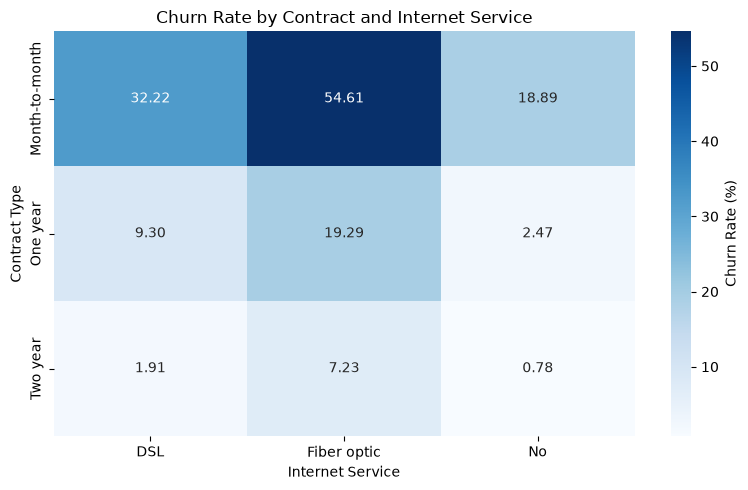

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.heatmap(
    contract_internet_churn,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract Type")
plt.tight_layout()
plt.show()

In [34]:
payment_churn = (
    df.groupby("Payment Method")["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print("Churn rate by payment method:")
print(payment_churn)

Churn rate by payment method:
Payment Method
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn Value, dtype: float64


In [35]:
payment_contract_churn = (
    df.groupby(["Payment Method", "Contract"])["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

print(payment_contract_churn)



Contract                   Month-to-month  One year  Two year
Payment Method                                               
Bank transfer (automatic)           34.13      9.72      3.37
Credit card (automatic)             32.78     10.30      2.24
Electronic check                    53.73     18.44      7.74
Mailed check                        31.58      6.82      0.79


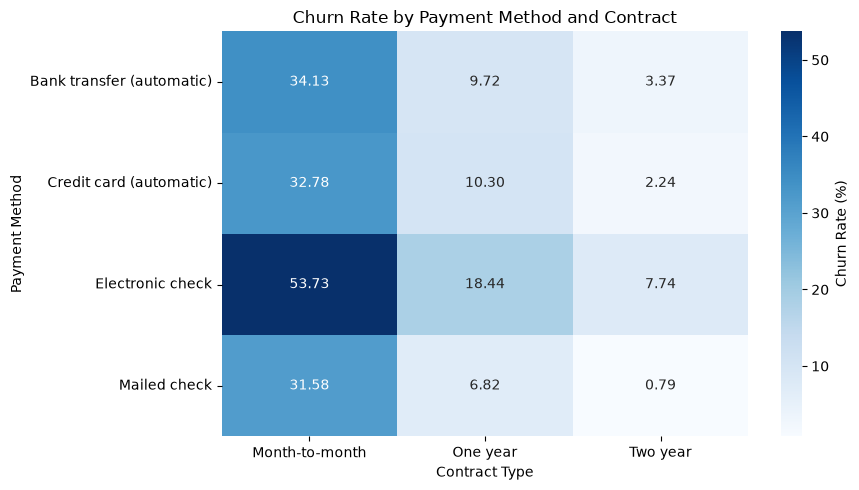

In [36]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    payment_contract_churn,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Churn Rate by Payment Method and Contract")
plt.xlabel("Contract Type")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

In [37]:
df["Tenure Band"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0–6 months", "7–12 months", "13–24 months", "25–48 months", "49–72 months"]
)

tenure_band_churn = (
    df.groupby("Tenure Band", observed=True)["Churn Value"]
      .mean()
      .mul(100)
      .round(2)
)

print("Churn rate by tenure band:")
print(tenure_band_churn)

Churn rate by tenure band:
Tenure Band
0–6 months      52.94
7–12 months     35.89
13–24 months    28.71
25–48 months    20.39
49–72 months     9.51
Name: Churn Value, dtype: float64


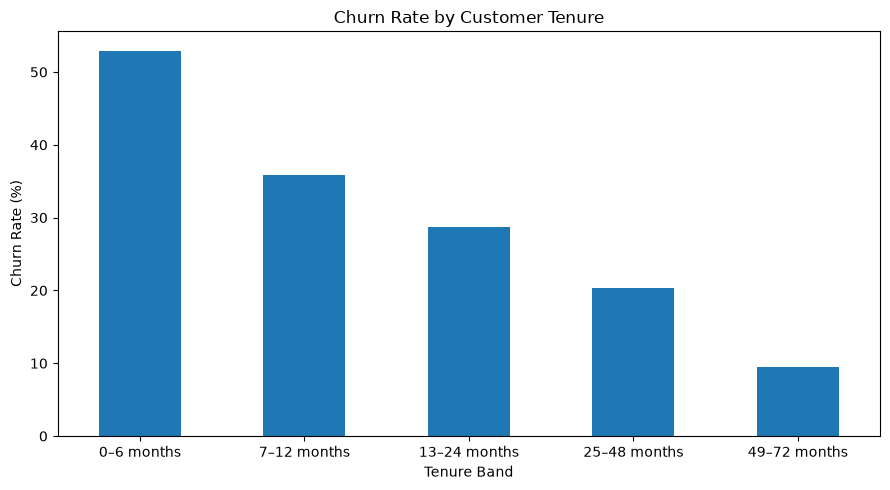

In [38]:
plt.figure(figsize=(9, 5))

tenure_band_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
risk_segments = (
    df.groupby(
        ["Tenure Band", "Contract", "Internet Service"],
        observed=True
    )["Churn Value"]
    .agg(["count", "mean"])
)

risk_segments["Churn Rate (%)"] = (
    risk_segments["mean"] * 100
).round(2)

risk_segments = risk_segments.drop(columns="mean")

risk_segments = risk_segments.sort_values(
    "Churn Rate (%)",
    ascending=False
)

print(risk_segments.head(15))

                                              count  Churn Rate (%)
Tenure Band  Contract       Internet Service                       
0–6 months   One year       Fiber optic           1          100.00
             Month-to-month Fiber optic         619           74.15
7–12 months  Month-to-month Fiber optic         297           61.95
13–24 months Month-to-month Fiber optic         425           50.59
49–72 months Month-to-month No                    2           50.00
0–6 months   Month-to-month DSL                 495           49.49
25–48 months Month-to-month Fiber optic         521           43.38
49–72 months Month-to-month Fiber optic         266           29.32
0–6 months   Month-to-month No                  299           25.42
7–12 months  Month-to-month DSL                 195           24.62
13–24 months Month-to-month DSL                 232           23.71
25–48 months One year       Fiber optic         154           20.13
0–6 months   One year       DSL                 

In [40]:
high_risk = df[
    (df["Tenure Band"] == "0–6 months") &
    (df["Contract"] == "Month-to-month") &
    (df["Internet Service"] == "Fiber optic")
]

print("High-risk segment size:", len(high_risk))
print("Churned customers:", high_risk["Churn Value"].sum())
print("Churn rate:", round(high_risk["Churn Value"].mean() * 100, 2), "%")

High-risk segment size: 619
Churned customers: 459
Churn rate: 74.15 %


In [41]:
total_churned = df["Churn Value"].sum()

segment_churned = high_risk["Churn Value"].sum()

share_of_churn = (segment_churned / total_churned) * 100

print("Total churned customers:", total_churned)
print("Churned customers in high-risk segment:", segment_churned)
print("Share of all churn from this segment:", round(share_of_churn, 2), "%")

Total churned customers: 1869
Churned customers in high-risk segment: 459
Share of all churn from this segment: 24.56 %


In [42]:
segment_summary = (
    df.groupby(
        ["Tenure Band", "Contract", "Internet Service"],
        observed=True
    )
    .agg(
        Customers=("Churn Value", "size"),
        Churned=("Churn Value", "sum"),
        Churn_Rate=("Churn Value", "mean")
    )
)

segment_summary["Churn_Rate"] = (
    segment_summary["Churn_Rate"] * 100
).round(2)

# Only include segments with at least 100 customers
top_segments = (
    segment_summary[
        segment_summary["Customers"] >= 100
    ]
    .sort_values("Churn_Rate", ascending=False)
    .head(10)
)

print(top_segments)

                                              Customers  Churned  Churn_Rate
Tenure Band  Contract       Internet Service                                
0–6 months   Month-to-month Fiber optic             619      459       74.15
7–12 months  Month-to-month Fiber optic             297      184       61.95
13–24 months Month-to-month Fiber optic             425      215       50.59
0–6 months   Month-to-month DSL                     495      245       49.49
25–48 months Month-to-month Fiber optic             521      226       43.38
49–72 months Month-to-month Fiber optic             266       78       29.32
0–6 months   Month-to-month No                      299       76       25.42
7–12 months  Month-to-month DSL                     195       48       24.62
13–24 months Month-to-month DSL                     232       55       23.71
25–48 months One year       Fiber optic             154       31       20.13


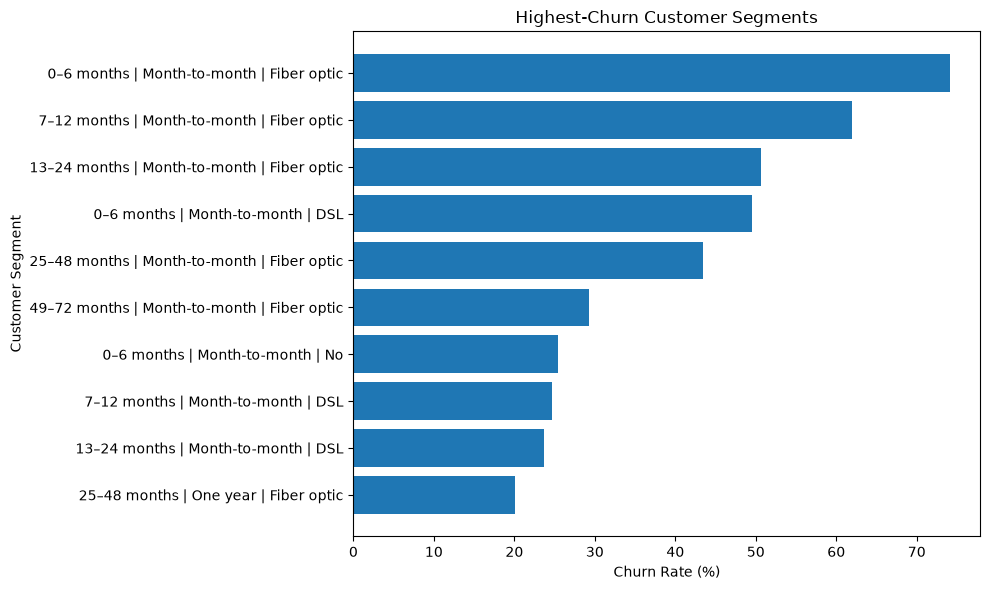

In [43]:
plt.figure(figsize=(10, 6))

labels = [
    f"{idx[0]} | {idx[1]} | {idx[2]}"
    for idx in top_segments.index
]

plt.barh(labels[::-1], top_segments["Churn_Rate"].values[::-1])

plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")
plt.title("Highest-Churn Customer Segments")
plt.tight_layout()
plt.show()

In [44]:
import os

os.makedirs("../data_cleaned", exist_ok=True)

output_path = "../data_cleaned/telco_customer_churn_analysis.csv"

df.to_csv(output_path, index=False)

print("Final analysis dataset saved successfully!")
print(output_path)

Final analysis dataset saved successfully!
../data_cleaned/telco_customer_churn_analysis.csv
